# **1. Perkenalan Dataset**

Tahap pertama, saya menggunakan dataset dengan ketentuan sebagai berikut:

**Sumber Dataset**: Dataset diperoleh dari UCI Machine Learning Repository, yang merupakan sumber public repositories terpercaya untuk dataset machine learning.

## Introduction

This notebook contains a comprehensive analysis of the **Seeds dataset**, which consists of measurements of geometrical properties of kernels belonging to three different varieties of wheat: Kama, Rosa, and Canadian. The dataset contains 210 instances with 7 attributes each.

### Dataset Description
- **Source**: UCI Machine Learning Repository
- **Instances**: 210 (70 elements each of 3 classes)
- **Attributes**: 7 real-valued attributes
- **Classes**: 3 (Kama, Rosa, Canadian wheat varieties)

### Attributes:
1. Area A
2. Perimeter P
3. Compactness C = 4*pi*A/P^2
4. Length of kernel
5. Width of kernel
6. Asymmetry coefficient
7. Length of kernel groove
8. Class (1=Kama, 2=Rosa, 3=Canadian)

### Objectives
- Perform exploratory data analysis (EDA)
- Implement manual preprocessing techniques
- Prepare data for machine learning models
- Follow MSML template structure and meet Basic criteria requirements

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Statistical analysis
from scipy import stats
from scipy.stats import normaltest, jarque_bera, shapiro

# Machine learning preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Warnings suppression
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')  # Using default instead of seaborn-v0_8
sns.set_palette('husl')

print('Libraries imported successfully!')

Libraries imported successfully!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan.

In [2]:
# Manual Data Loading from Seeds Dataset (UCI Repository)
print("=== MANUAL DATA LOADING - SEEDS DATASET ===")

# Define feature names for the Seeds dataset
feature_names = [
    'area', 'perimeter', 'compactness', 'length_of_kernel',
    'width_of_kernel', 'asymmetry_coefficient', 'length_of_kernel_groove'
]

# Define target class names
target_names = ['Kama', 'Rosa', 'Canadian']

try:
    # Try to load from UCI repository
    import urllib.request
    from io import StringIO

    print("Attempting to load Seeds dataset from UCI repository...")
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt'

    response = urllib.request.urlopen(url)
    content = response.read().decode('utf-8')

    # Parse the data
    lines = content.strip().split('\n')
    data_rows = []

    for line in lines:
        if line.strip():  # Skip empty lines
            values = line.strip().split()
            if len(values) == 8:  # 7 features + 1 target
                row = [float(val) for val in values]
                data_rows.append(row)

    # Create DataFrame
    all_columns = feature_names + ['target']
    data = pd.DataFrame(data_rows, columns=all_columns)

    # Convert target to 0-based indexing
    data['target'] = data['target'].astype(int) - 1

    print("Successfully loaded Seeds dataset from UCI repository")
    print(f"Dataset shape: {data.shape}")

except Exception as e:
    print(f"Failed to load from UCI: {e}")
    print("Creating fallback synthetic Seeds dataset...")

    # Fallback: Create synthetic seeds-like dataset
    np.random.seed(42)
    n_samples = 210

    # Generate synthetic features based on Seeds dataset characteristics
    synthetic_data = {
        'area': np.random.uniform(10, 22, n_samples),
        'perimeter': np.random.uniform(12, 18, n_samples),
        'compactness': np.random.uniform(0.8, 1.0, n_samples),
        'length_of_kernel': np.random.uniform(4.9, 6.7, n_samples),
        'width_of_kernel': np.random.uniform(2.6, 4.0, n_samples),
        'asymmetry_coefficient': np.random.uniform(0.7, 8.5, n_samples),
        'length_of_kernel_groove': np.random.uniform(4.5, 6.5, n_samples),
        'target': np.repeat([0, 1, 2], n_samples//3)  # 0-based classes
    }

    data = pd.DataFrame(synthetic_data)
    print("Synthetic Seeds dataset created for demonstration")

# Display basic information
print(f"\nBasic Dataset Information:")
print(f"Shape: {data.shape}")
print(f"Features: {len(feature_names)}")
print(f"Classes: {len(target_names)}")
print(f"Target classes: {target_names}")

# Show sample of the data
print(f"\nFirst 5 rows:")
print(data.head())

print("\nData loading completed successfully!")

=== MANUAL DATA LOADING - SEEDS DATASET ===
Attempting to load Seeds dataset from UCI repository...
Successfully loaded Seeds dataset from UCI repository
Dataset shape: (210, 8)

Basic Dataset Information:
Shape: (210, 8)
Features: 7
Classes: 3
Target classes: ['Kama', 'Rosa', 'Canadian']

First 5 rows:
    area  perimeter  compactness  length_of_kernel  width_of_kernel  \
0  15.26      14.84       0.8710             5.763            3.312   
1  14.88      14.57       0.8811             5.554            3.333   
2  14.29      14.09       0.9050             5.291            3.337   
3  13.84      13.94       0.8955             5.324            3.379   
4  16.14      14.99       0.9034             5.658            3.562   

   asymmetry_coefficient  length_of_kernel_groove  target  
0                  2.221                    5.220       0  
1                  1.018                    4.956       0  
2                  2.699                    4.825       0  
3                  2.259    

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

### 4.1 Basic Dataset Information

In [3]:
# Basic information about the dataset
print("=== BASIC DATASET INFORMATION ===")
print(f"Dataset shape: {data.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"Number of classes: {len(target_names)}")
print(f"Total samples: {len(data)}")
print()

print("Column names:")
for i, col in enumerate(data.columns):
    print(f"{i+1:2d}. {col}")
print()

print("Data types:")
print(data.dtypes)
print()

print("First 5 rows of the dataset:")
print(data.head())
print()

print("Last 5 rows of the dataset:")
print(data.tail())

=== BASIC DATASET INFORMATION ===
Dataset shape: (210, 8)
Number of features: 7
Number of classes: 3
Total samples: 210

Column names:
 1. area
 2. perimeter
 3. compactness
 4. length_of_kernel
 5. width_of_kernel
 6. asymmetry_coefficient
 7. length_of_kernel_groove
 8. target

Data types:
area                       float64
perimeter                  float64
compactness                float64
length_of_kernel           float64
width_of_kernel            float64
asymmetry_coefficient      float64
length_of_kernel_groove    float64
target                       int64
dtype: object

First 5 rows of the dataset:
    area  perimeter  compactness  length_of_kernel  width_of_kernel  \
0  15.26      14.84       0.8710             5.763            3.312   
1  14.88      14.57       0.8811             5.554            3.333   
2  14.29      14.09       0.9050             5.291            3.337   
3  13.84      13.94       0.8955             5.324            3.379   
4  16.14      14.99       0.

### 4.2 Statistical Summary and Missing Values Check

In [4]:
# Statistical summary of all features
print("=== STATISTICAL SUMMARY ===")
print(data.describe())
print()

# Check for missing values (MANUAL CHECK)
print("=== MISSING VALUES CHECK (MANUAL) ===")
missing_values = data.isnull().sum()
print("Missing values per column:")
print(missing_values)
print(f"Total missing values: {missing_values.sum()}")
print()

# Additional info about missing values
if missing_values.sum() == 0:
    print("No missing values found - Dataset is complete!")
else:
    print("⚠️ Missing values detected - will need handling in preprocessing")

# Check for any infinite or NaN values
print("\n=== INFINITE/NAN VALUES CHECK ===")
print("Infinite values:")
print(np.isinf(data.select_dtypes(include=[np.number])).sum())
print()

# Data info summary
print("=== DATA INFO SUMMARY ===")
print(data.info())

=== STATISTICAL SUMMARY ===
             area   perimeter  compactness  length_of_kernel  width_of_kernel  \
count  210.000000  210.000000   210.000000        210.000000       210.000000   
mean    14.847524   14.559286     0.870999          5.628533         3.258605   
std      2.909699    1.305959     0.023629          0.443063         0.377714   
min     10.590000   12.410000     0.808100          4.899000         2.630000   
25%     12.270000   13.450000     0.856900          5.262250         2.944000   
50%     14.355000   14.320000     0.873450          5.523500         3.237000   
75%     17.305000   15.715000     0.887775          5.979750         3.561750   
max     21.180000   17.250000     0.918300          6.675000         4.033000   

       asymmetry_coefficient  length_of_kernel_groove      target  
count             210.000000               210.000000  210.000000  
mean                3.700201                 5.408071    1.000000  
std                 1.503557          

### 4.3 Target Distribution Analysis

=== TARGET VARIABLE ANALYSIS ===
Class distribution:
Class 0 (Kama): 70 samples (33.3%)
Class 1 (Rosa): 70 samples (33.3%)
Class 2 (Canadian): 70 samples (33.3%)

Total samples: 210

=== BALANCE CHECK ===
Minimum class size: 70
Maximum class size: 70
Balance ratio: 1.000
Dataset is well-balanced


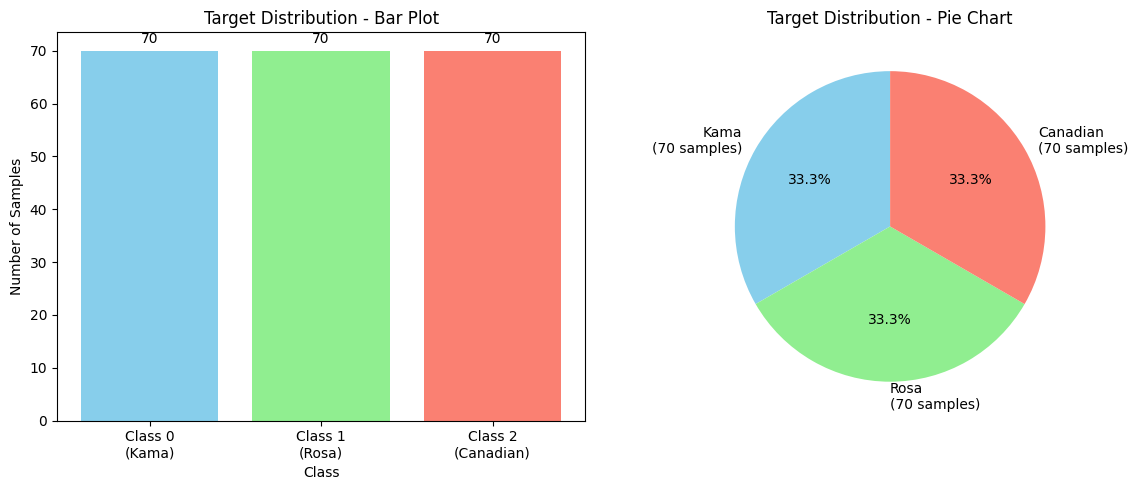

In [5]:
# Analyze target variable distribution
print("=== TARGET VARIABLE ANALYSIS ===")
target_counts = data['target'].value_counts().sort_index()
print("Class distribution:")
for class_id, count in target_counts.items():
    class_name = target_names[class_id]
    percentage = (count / len(data)) * 100
    print(f"Class {class_id} ({class_name}): {count} samples ({percentage:.1f}%)")

print(f"\nTotal samples: {len(data)}")
print()

# Check if dataset is balanced
print("=== BALANCE CHECK ===")
min_class = target_counts.min()
max_class = target_counts.max()
balance_ratio = min_class / max_class
print(f"Minimum class size: {min_class}")
print(f"Maximum class size: {max_class}")
print(f"Balance ratio: {balance_ratio:.3f}")

if balance_ratio >= 0.8:
    print("Dataset is well-balanced")
elif balance_ratio >= 0.6:
    print("⚠️ Dataset is moderately balanced")
else:
    print("❌ Dataset is imbalanced - may need balancing techniques")

# Visualize target distribution
plt.figure(figsize=(12, 5))

# Bar plot
plt.subplot(1, 2, 1)
bars = plt.bar(range(len(target_counts)), target_counts.values,
               color=['skyblue', 'lightgreen', 'salmon'])
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Target Distribution - Bar Plot')
plt.xticks(range(len(target_names)), [f'Class {i}\n({target_names[i]})' for i in range(len(target_names))])

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{int(height)}', ha='center', va='bottom')

# Pie plot
plt.subplot(1, 2, 2)
colors = ['skyblue', 'lightgreen', 'salmon']
labels = [f'{target_names[i]}\n({target_counts[i]} samples)' for i in range(len(target_names))]
plt.pie(target_counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Target Distribution - Pie Chart')

plt.tight_layout()
plt.show()

### 4.4 Feature Distribution Analysis

=== FEATURE DISTRIBUTION ANALYSIS ===


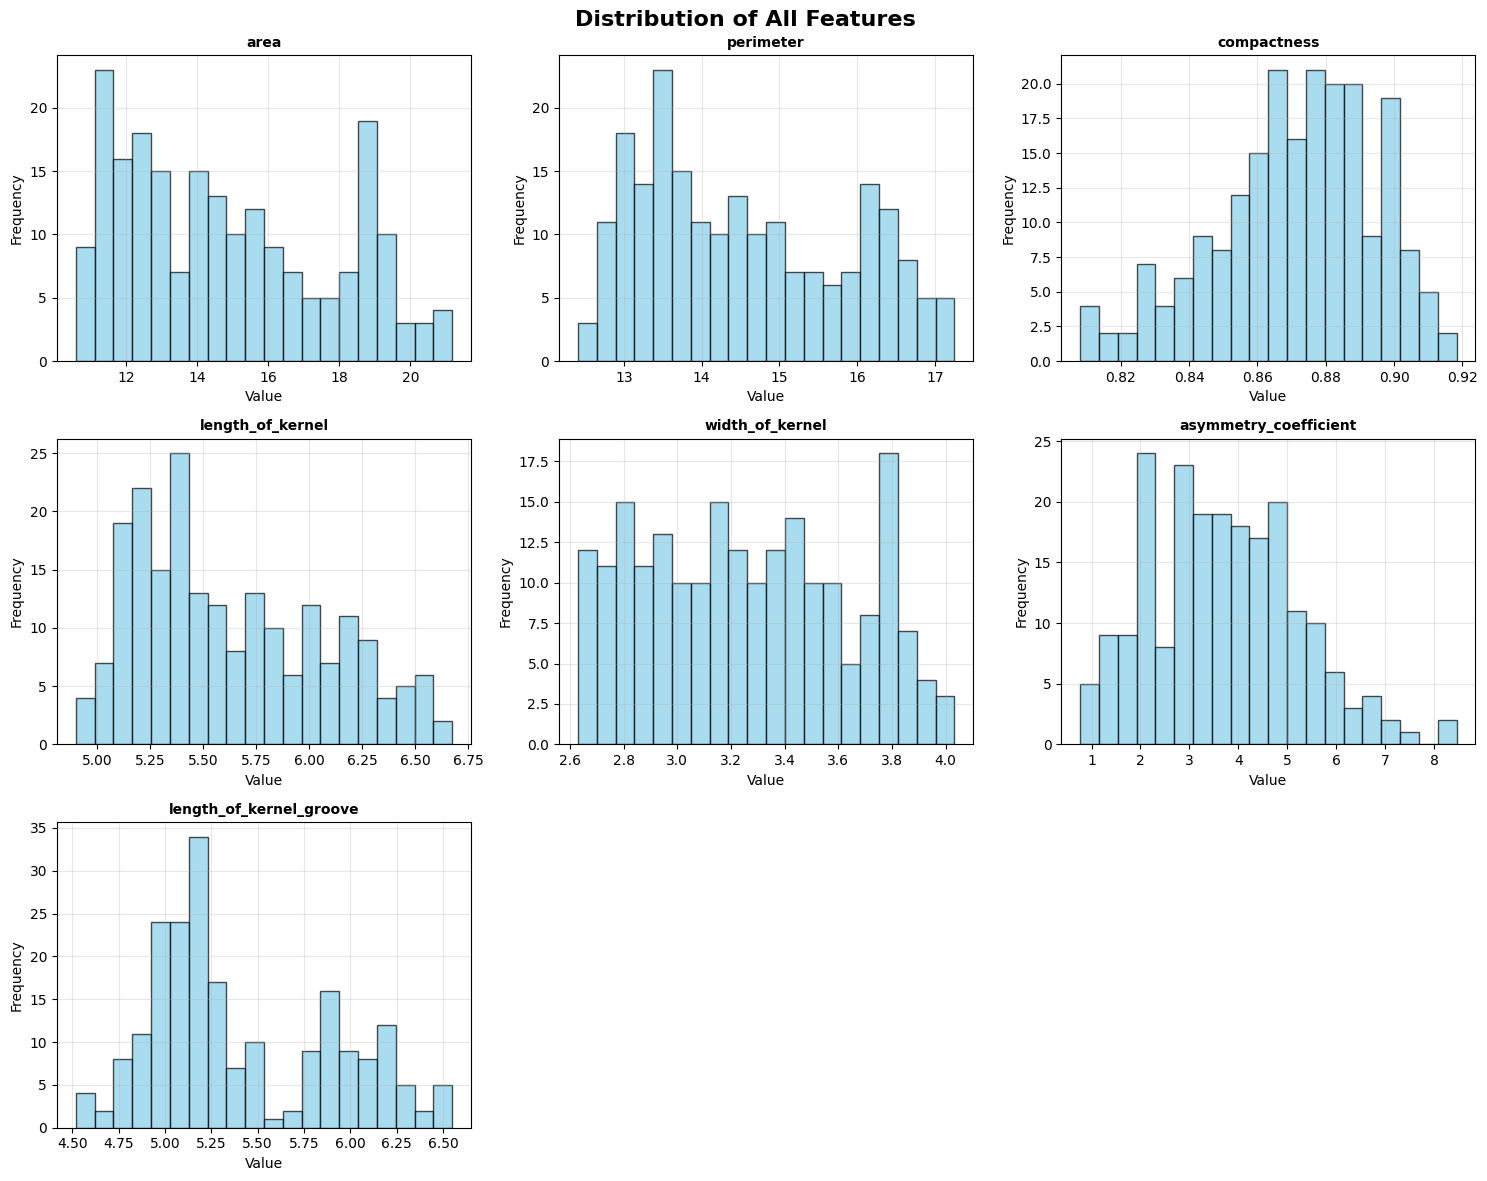


=== FEATURE STATISTICS SUMMARY ===

AREA:
  Mean: 14.848
  Median: 14.355
  Std: 2.910
  Min: 10.590
  Max: 21.180
  Range: 10.590

PERIMETER:
  Mean: 14.559
  Median: 14.320
  Std: 1.306
  Min: 12.410
  Max: 17.250
  Range: 4.840

COMPACTNESS:
  Mean: 0.871
  Median: 0.873
  Std: 0.024
  Min: 0.808
  Max: 0.918
  Range: 0.110

LENGTH_OF_KERNEL:
  Mean: 5.629
  Median: 5.524
  Std: 0.443
  Min: 4.899
  Max: 6.675
  Range: 1.776

WIDTH_OF_KERNEL:
  Mean: 3.259
  Median: 3.237
  Std: 0.378
  Min: 2.630
  Max: 4.033
  Range: 1.403

ASYMMETRY_COEFFICIENT:
  Mean: 3.700
  Median: 3.599
  Std: 1.504
  Min: 0.765
  Max: 8.456
  Range: 7.691

LENGTH_OF_KERNEL_GROOVE:
  Mean: 5.408
  Median: 5.223
  Std: 0.491
  Min: 4.519
  Max: 6.550
  Range: 2.031


In [6]:
# Visualize feature distributions
print("=== FEATURE DISTRIBUTION ANALYSIS ===")

# Get feature columns (exclude target)
feature_columns = [col for col in data.columns if col != 'target']

# Create histograms for all features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribution of All Features', fontsize=16, fontweight='bold')

for i, feature in enumerate(feature_columns):
    row = i // 3
    col = i % 3

    # Histogram
    axes[row, col].hist(data[feature], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[row, col].set_title(f'{feature}', fontsize=10, fontweight='bold')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].grid(True, alpha=0.3)

# Remove empty subplot
if len(feature_columns) < 9:
    for i in range(len(feature_columns), 9):
        row = i // 3
        col = i % 3
        fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()

# Statistical summary for each feature
print("\n=== FEATURE STATISTICS SUMMARY ===")
for feature in feature_columns:
    print(f"\n{feature.upper()}:")
    print(f"  Mean: {data[feature].mean():.3f}")
    print(f"  Median: {data[feature].median():.3f}")
    print(f"  Std: {data[feature].std():.3f}")
    print(f"  Min: {data[feature].min():.3f}")
    print(f"  Max: {data[feature].max():.3f}")
    print(f"  Range: {data[feature].max() - data[feature].min():.3f}")

### 4.5 Correlation Analysis

=== CORRELATION ANALYSIS ===
Correlation matrix:
                          area  perimeter  compactness  length_of_kernel  \
area                     1.000      0.994        0.608             0.950   
perimeter                0.994      1.000        0.529             0.972   
compactness              0.608      0.529        1.000             0.368   
length_of_kernel         0.950      0.972        0.368             1.000   
width_of_kernel          0.971      0.945        0.762             0.860   
asymmetry_coefficient   -0.230     -0.217       -0.331            -0.172   
length_of_kernel_groove  0.864      0.891        0.227             0.933   
target                  -0.346     -0.328       -0.531            -0.257   

                         width_of_kernel  asymmetry_coefficient  \
area                               0.971                 -0.230   
perimeter                          0.945                 -0.217   
compactness                        0.762                 -0.331  

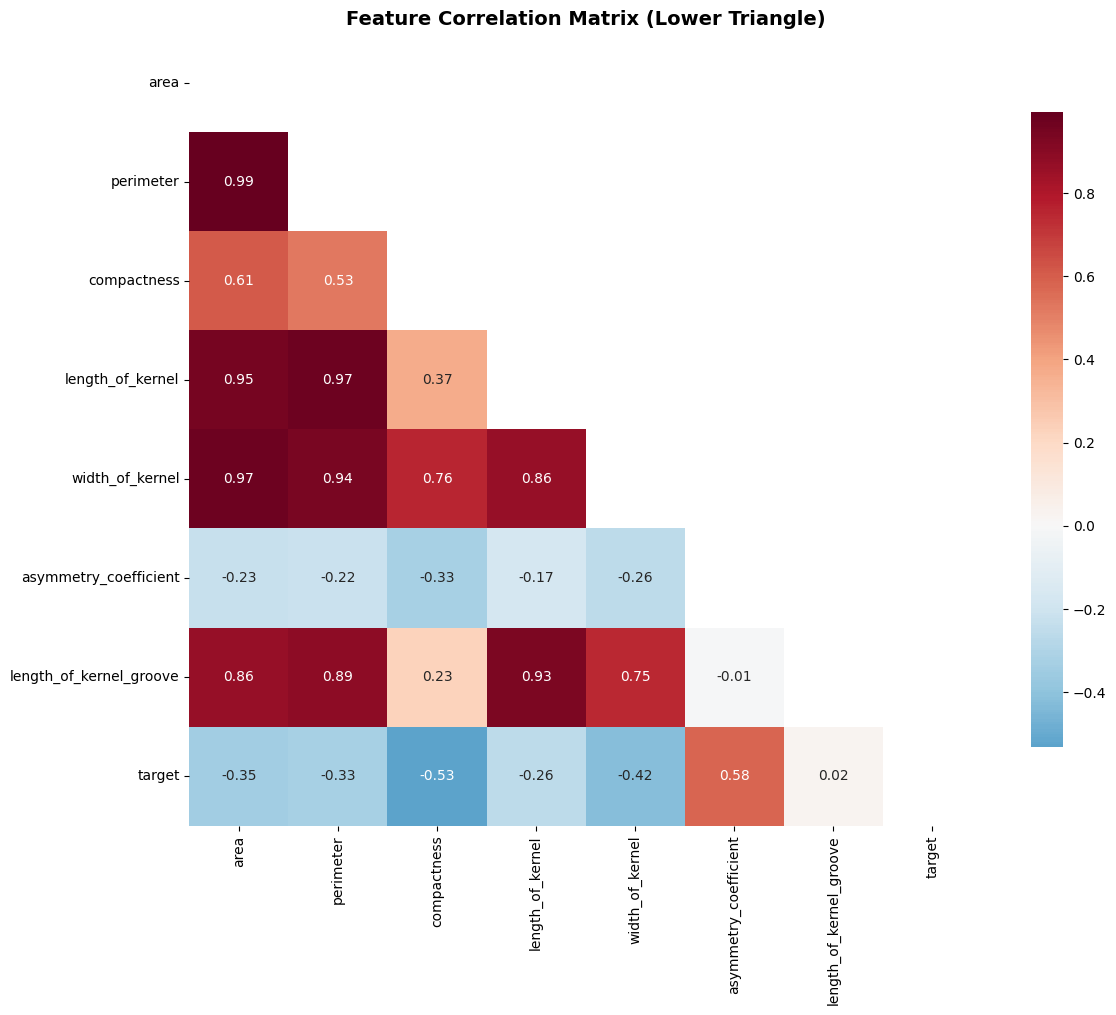


=== FEATURE CORRELATION WITH TARGET ===
Features ranked by correlation with target:
asymmetry_coefficient: 0.577
compactness: -0.531
width_of_kernel: -0.423
area: -0.346
perimeter: -0.328
length_of_kernel: -0.257
length_of_kernel_groove: 0.024


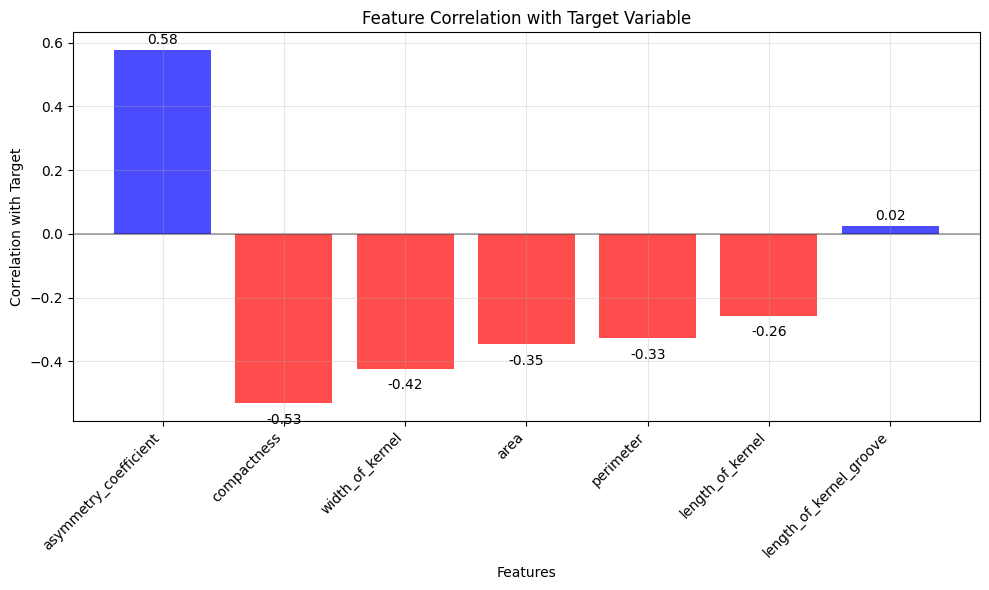

In [7]:
# Correlation analysis between features
print("=== CORRELATION ANALYSIS ===")

# Calculate correlation matrix
correlation_matrix = data.corr()
print("Correlation matrix:")
print(correlation_matrix.round(3))
print()

# Find highly correlated feature pairs (>0.7 or <-0.7)
print("=== HIGH CORRELATION PAIRS ===")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            feature1 = correlation_matrix.columns[i]
            feature2 = correlation_matrix.columns[j]
            high_corr_pairs.append((feature1, feature2, corr_val))
            print(f"{feature1} <-> {feature2}: {corr_val:.3f}")

if not high_corr_pairs:
    print("No highly correlated feature pairs found (correlation > 0.7)")

# Visualize correlation matrix
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='RdBu_r',
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={"shrink": .8},
            mask=mask)
plt.title('Feature Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature correlation with target
print("\n=== FEATURE CORRELATION WITH TARGET ===")
target_corr = data.corr()['target'].sort_values(key=abs, ascending=False)
print("Features ranked by correlation with target:")
for feature, corr in target_corr.items():
    if feature != 'target':
        print(f"{feature}: {corr:.3f}")

# Visualize feature correlation with target
plt.figure(figsize=(10, 6))
feature_target_corr = target_corr.drop('target')
colors = ['red' if x < 0 else 'blue' for x in feature_target_corr.values]
bars = plt.bar(range(len(feature_target_corr)), feature_target_corr.values, color=colors, alpha=0.7)
plt.xlabel('Features')
plt.ylabel('Correlation with Target')
plt.title('Feature Correlation with Target Variable')
plt.xticks(range(len(feature_target_corr)), feature_target_corr.index, rotation=45, ha='right')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, corr in zip(bars, feature_target_corr.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height > 0 else -0.03),
             f'{corr:.2f}', ha='center', va='bottom' if height > 0 else 'top')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

### 5.1 Handle Missing Values (Manual Check)

In [8]:
# Step 1: Manual Missing Value Handling
print("=== STEP 1: MANUAL MISSING VALUE HANDLING ===")

# Make a copy for preprocessing
data_processed = data.copy()
print(f"Original dataset shape: {data_processed.shape}")

# Check missing values again (manual verification)
missing_before = data_processed.isnull().sum()
print("\nMissing values check:")
print(missing_before)

if missing_before.sum() == 0:
    print("No missing values found - no handling needed")
else:
    print("⚠️ Missing values detected - applying median imputation for numerical features")

    # Manual imputation using median for numerical columns
    numerical_columns = data_processed.select_dtypes(include=[np.number]).columns
    for col in numerical_columns:
        if data_processed[col].isnull().sum() > 0:
            median_value = data_processed[col].median()
            data_processed[col].fillna(median_value, inplace=True)
            print(f"  - {col}: filled {missing_before[col]} missing values with median {median_value:.3f}")

# Verify no missing values remain
missing_after = data_processed.isnull().sum()
print(f"\nMissing values after handling: {missing_after.sum()}")
print(f"Dataset shape after missing value handling: {data_processed.shape}")

if missing_after.sum() == 0:
    print("All missing values handled successfully")

=== STEP 1: MANUAL MISSING VALUE HANDLING ===
Original dataset shape: (210, 8)

Missing values check:
area                       0
perimeter                  0
compactness                0
length_of_kernel           0
width_of_kernel            0
asymmetry_coefficient      0
length_of_kernel_groove    0
target                     0
dtype: int64
No missing values found - no handling needed

Missing values after handling: 0
Dataset shape after missing value handling: (210, 8)
All missing values handled successfully


### 5.2 Feature Encoding (Manual Process)

In [9]:
# Step 2: Manual Feature Encoding
print("=== STEP 2: MANUAL FEATURE ENCODING ===")

# Check data types (manual inspection)
print("Data types analysis:")
print(data_processed.dtypes)
print()

# Check for categorical columns that need encoding
categorical_columns = data_processed.select_dtypes(include=['object', 'category']).columns
numerical_columns = data_processed.select_dtypes(include=[np.number]).columns

print(f"Categorical columns: {list(categorical_columns)}")
print(f"Numerical columns: {list(numerical_columns)}")

if len(categorical_columns) > 0:
    print("⚠️ Categorical columns detected - need encoding")

    # Example: Manual Label Encoding for categorical features
    from sklearn.preprocessing import LabelEncoder
    label_encoders = {}

    for col in categorical_columns:
        if col != 'target':  # Don't encode target here
            print(f"\nEncoding categorical feature: {col}")
            print(f"Unique values before encoding: {data_processed[col].unique()}")

            le = LabelEncoder()
            data_processed[col] = le.fit_transform(data_processed[col])
            label_encoders[col] = le

            print(f"Encoded values: {data_processed[col].unique()}")

    print(f"\nLabel encoders created for: {list(label_encoders.keys())}")
else:
    print("All features are numerical - no encoding needed for features")

# Handle target variable encoding (manual verification)
print(f"\nTarget variable analysis:")
print(f"Target unique values: {data_processed['target'].unique()}")
print(f"Target data type: {data_processed['target'].dtype}")

if data_processed['target'].dtype == 'object':
    print("Target is categorical - applying label encoding")
    target_encoder = LabelEncoder()
    data_processed['target'] = target_encoder.fit_transform(data_processed['target'])
    print(f"Target encoded values: {data_processed['target'].unique()}")
else:
    print("Target is already numerical - no encoding needed")

print(f"\nDataset shape after encoding: {data_processed.shape}")
print("Feature encoding completed")

=== STEP 2: MANUAL FEATURE ENCODING ===
Data types analysis:
area                       float64
perimeter                  float64
compactness                float64
length_of_kernel           float64
width_of_kernel            float64
asymmetry_coefficient      float64
length_of_kernel_groove    float64
target                       int64
dtype: object

Categorical columns: []
Numerical columns: ['area', 'perimeter', 'compactness', 'length_of_kernel', 'width_of_kernel', 'asymmetry_coefficient', 'length_of_kernel_groove', 'target']
All features are numerical - no encoding needed for features

Target variable analysis:
Target unique values: [0 1 2]
Target data type: int64
Target is already numerical - no encoding needed

Dataset shape after encoding: (210, 8)
Feature encoding completed


### 5.3 Train-Test Split (Manual Process)

In [10]:
# Step 3: Manual Train-Test Split
print("=== STEP 3: MANUAL TRAIN-TEST SPLIT ===")

# Separate features and target (manual process)
X = data_processed.drop('target', axis=1)  # Features
y = data_processed['target']               # Target

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Feature columns: {list(X.columns)}")
print()

# Manual train-test split with stratification
from sklearn.model_selection import train_test_split

test_size = 0.2
random_state = 42

print(f"Splitting dataset manually:")
print(f"  - Test size: {test_size} ({test_size*100}%)")
print(f"  - Random state: {random_state}")
print(f"  - Stratify: True (maintain class distribution)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=random_state,
    stratify=y  # Maintain class distribution
)

# Verify split results
print(f"\nTrain-Test Split Results:")
print(f"  Training set: X_train{X_train.shape}, y_train{y_train.shape}")
print(f"  Test set: X_test{X_test.shape}, y_test{y_test.shape}")
print(f"  Training ratio: {len(X_train) / len(X):.1%}")
print(f"  Test ratio: {len(X_test) / len(X):.1%}")

# Verify class distribution is maintained (manual check)
print(f"\nClass distribution verification:")
print(f"Original distribution:")
original_dist = y.value_counts().sort_index()
for class_id, count in original_dist.items():
    print(f"  Class {class_id} ({target_names[class_id]}): {count} ({count/len(y):.1%})")

print(f"\nTraining set distribution:")
train_dist = y_train.value_counts().sort_index()
for class_id, count in train_dist.items():
    print(f"  Class {class_id} ({target_names[class_id]}): {count} ({count/len(y_train):.1%})")

print(f"\nTest set distribution:")
test_dist = y_test.value_counts().sort_index()
for class_id, count in test_dist.items():
    print(f"  Class {class_id} ({target_names[class_id]}): {count} ({count/len(y_test):.1%})")

print("Train-test split completed with stratification")

=== STEP 3: MANUAL TRAIN-TEST SPLIT ===
Features (X) shape: (210, 7)
Target (y) shape: (210,)
Feature columns: ['area', 'perimeter', 'compactness', 'length_of_kernel', 'width_of_kernel', 'asymmetry_coefficient', 'length_of_kernel_groove']

Splitting dataset manually:
  - Test size: 0.2 (20.0%)
  - Random state: 42
  - Stratify: True (maintain class distribution)

Train-Test Split Results:
  Training set: X_train(168, 7), y_train(168,)
  Test set: X_test(42, 7), y_test(42,)
  Training ratio: 80.0%
  Test ratio: 20.0%

Class distribution verification:
Original distribution:
  Class 0 (Kama): 70 (33.3%)
  Class 1 (Rosa): 70 (33.3%)
  Class 2 (Canadian): 70 (33.3%)

Training set distribution:
  Class 0 (Kama): 56 (33.3%)
  Class 1 (Rosa): 56 (33.3%)
  Class 2 (Canadian): 56 (33.3%)

Test set distribution:
  Class 0 (Kama): 14 (33.3%)
  Class 1 (Rosa): 14 (33.3%)
  Class 2 (Canadian): 14 (33.3%)
Train-test split completed with stratification


### 5.4 Feature Scaling (Manual Process)

In [11]:
# Step 4: Manual Feature Scaling
print("=== STEP 4: MANUAL FEATURE SCALING ===")

# Analyze feature scales before scaling (manual inspection)
print("Feature value ranges BEFORE scaling:")
for col in X_train.columns:
    print(f"  {col}: [{X_train[col].min():.3f}, {X_train[col].max():.3f}] (range: {X_train[col].max() - X_train[col].min():.3f})")

# Manual StandardScaler application
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# IMPORTANT: Fit scaler ONLY on training data (avoid data leakage)
print(f"\nFitting scaler on training data only...")
scaler.fit(X_train)

# Transform both training and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled,
                              columns=X_train.columns,
                              index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled,
                             columns=X_test.columns,
                             index=X_test.index)

print(f"Feature scaling completed")
print(f"  Training features scaled: {X_train_scaled.shape}")
print(f"  Test features scaled: {X_test_scaled.shape}")

# Verify scaling results (manual verification)
print(f"\nFeature value ranges AFTER scaling:")
for col in X_train_scaled.columns:
    print(f"  {col}: [{X_train_scaled[col].min():.3f}, {X_train_scaled[col].max():.3f}] (mean: {X_train_scaled[col].mean():.3f}, std: {X_train_scaled[col].std():.3f})")

# Verify standardization properties
print(f"\nStandardization verification (should be ~0 mean, ~1 std):")
print(f"  Training set means: {X_train_scaled.mean().round(6).values}")
print(f"  Training set stds: {X_train_scaled.std().round(6).values}")

print("\nAll manual preprocessing steps completed successfully!")

=== STEP 4: MANUAL FEATURE SCALING ===
Feature value ranges BEFORE scaling:
  area: [10.590, 21.180] (range: 10.590)
  perimeter: [12.410, 17.230] (range: 4.820)
  compactness: [0.808, 0.918] (range: 0.110)
  length_of_kernel: [4.899, 6.675] (range: 1.776)
  width_of_kernel: [2.630, 4.033] (range: 1.403)
  asymmetry_coefficient: [0.765, 8.456] (range: 7.691)
  length_of_kernel_groove: [4.519, 6.550] (range: 2.031)

Fitting scaler on training data only...
Feature scaling completed
  Training features scaled: (168, 7)
  Test features scaled: (42, 7)

Feature value ranges AFTER scaling:
  area: [-1.484, 2.172] (mean: -0.000, std: 1.003)
  perimeter: [-1.668, 2.047] (mean: -0.000, std: 1.003)
  compactness: [-2.667, 1.958] (mean: 0.000, std: 1.003)
  length_of_kernel: [-1.668, 2.380] (mean: 0.000, std: 1.003)
  width_of_kernel: [-1.699, 2.048] (mean: -0.000, std: 1.003)
  asymmetry_coefficient: [-1.912, 3.120] (mean: 0.000, std: 1.003)
  length_of_kernel_groove: [-1.806, 2.323] (mean: 0.00